# **METODY SYSTEMOWE I DECYZYJNE LISTA 2**
Celem tej listy jest zrozumienie, jak działają klasyczne algorytmy uczenia maszynowego. Ten projekt zawiera samodzielnie zaimplementowane podstawowe algorytmy i porównanie ich wyników z gotowymi rozwiązaniami z biblioteki scikit-learn.

### Zbiór danych:
Wybrane zmienne docelowe w projekcie:
* dla problemu klasyfikacji `felt_rested`
* dla problemu regresji `cognitive_performance_score`

In [1]:
VERBOSE = False

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, mean_squared_error)


plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
np.set_printoptions(suppress=True)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Decision Tree Classification Model
 Wytrenowanie modelu klasyfikacyjnego do przewidywania zmiennej 'felt_rested'
 na podstawie zbioru sleep_health_dataset.csv.


### Wczytywanie i preprocessing dancyh


In [3]:
file_path = "../resources/sleep_health_dataset.csv"
df = pd.read_csv(file_path)

if 'person_id' in df.columns:
    df = df.drop('person_id', axis=1)

if VERBOSE:
    print(f"\nRozmiar calego zbioru danych: {df.shape[0]} wierszy x {df.shape[1]} kolumn\n")
    df.info()
    df.describe().round(5)

In [4]:
categorical_cols = df.select_dtypes(include=['str']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if VERBOSE:
    print(f"\nZmienne kategoryczne: {categorical_cols}")
    print(f"Zmienne numeryczne: {numerical_cols}")


label_encoders = {}
df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"\nKodowanie {col}:")
    for i, class_name in enumerate(le.classes_):
        print(f"  {class_name} -> {i}")

if VERBOSE: df_encoded.head(5)


Kodowanie gender:
  Female -> 0
  Male -> 1
  Other -> 2

Kodowanie occupation:
  Doctor -> 0
  Driver -> 1
  Freelancer -> 2
  Homemaker -> 3
  Lawyer -> 4
  Manager -> 5
  Nurse -> 6
  Retired -> 7
  Sales -> 8
  Software Engineer -> 9
  Student -> 10
  Teacher -> 11

Kodowanie country:
  Australia -> 0
  Brazil -> 1
  Canada -> 2
  France -> 3
  Germany -> 4
  India -> 5
  Italy -> 6
  Japan -> 7
  Mexico -> 8
  Netherlands -> 9
  South Korea -> 10
  Spain -> 11
  Sweden -> 12
  UK -> 13
  USA -> 14

Kodowanie chronotype:
  Evening -> 0
  Morning -> 1
  Neutral -> 2

Kodowanie mental_health_condition:
  Anxiety -> 0
  Both -> 1
  Depression -> 2
  Healthy -> 3

Kodowanie season:
  Autumn -> 0
  Spring -> 1
  Summer -> 2
  Winter -> 3

Kodowanie day_type:
  Weekday -> 0
  Weekend -> 1

Kodowanie sleep_disorder_risk:
  Healthy -> 0
  Mild -> 1
  Moderate -> 2
  Severe -> 3


In [5]:
target_col = 'felt_rested'
y = df_encoded[target_col]
X = df_encoded.drop(columns=[target_col])

if VERBOSE:
    print(f"\nZmienne niezalezne (cechy): {X.columns.tolist()}")
    print(f"\nZmienna zalezna (target): {target_col}")
    print(f"Klasy: {sorted(y.unique())}")
    print(f"\nRozklad klas:")
    print(y.value_counts())

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=13
)

if VERBOSE:
    print(f"\nRozmiar zbioru treningowego: {X_train.shape[0]} wierszy x {X_train.shape[1]} kolumn")
    print(f"Rozmiar zbioru testowego: {X_test.shape[0]} wierszy x {X_test.shape[1]} kolumn")

    print(f"\nRozklad klas w zbiorze treningowym:")
    print(pd.Series(y_train).value_counts())
    print(f"\nRozklad klas w zbiorze testowym:")
    print(pd.Series(y_test).value_counts())

## Trenowanie modelu decision tree classifier

In [7]:
dt_classifier = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=13,
    min_samples_split=10
)
dt_classifier.fit(X_train, y_train)

print(f"Glebokosc drzewa: {dt_classifier.get_depth()}")
print(f"Liczba lisci: {dt_classifier.get_n_leaves()}")

Glebokosc drzewa: 5
Liczba lisci: 32



Waznosc cech (Feature Importances):
                        feature  importance
6           sleep_quality_score    0.631041
5            sleep_duration_hrs    0.276701
10      wake_episodes_per_night    0.048881
17                 stress_score    0.039903
29          sleep_disorder_risk    0.001830
24     room_temperature_celsius    0.000686
7                rem_percentage    0.000554
28  cognitive_performance_score    0.000405
2                    occupation    0.000000
8         deep_sleep_percentage    0.000000
4                       country    0.000000
3                           bmi    0.000000
1                        gender    0.000000
0                           age    0.000000
13  screen_time_before_bed_mins    0.000000
12     alcohol_units_before_bed    0.000000
11       caffeine_mg_before_bed    0.000000
9            sleep_latency_mins    0.000000
18          work_hours_that_day    0.000000
14                 exercise_day    0.000000
15               steps_that_day    0.00

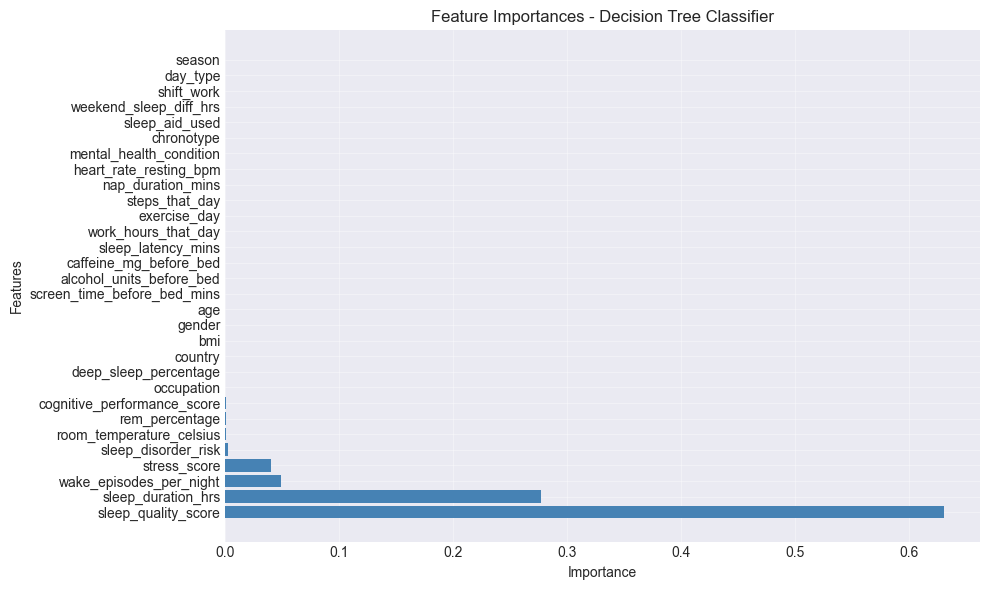

In [8]:
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nWaznosc cech (Feature Importances):")
print(feature_importances)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['feature'], feature_importances['importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importances - Decision Tree Classifier')
plt.tight_layout()
plt.show()

## Macierz pomyłek

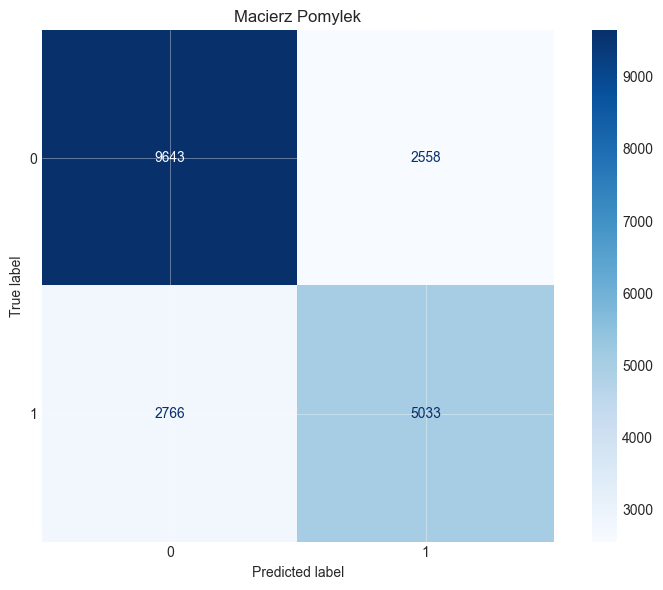

In [9]:
target_names = [str(i) for i in sorted(np.unique(y_test))]
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, cmap='Blues')
ax.set_title('Macierz Pomylek')
plt.tight_layout()
plt.show()

## Predykcje i ocena modelu

In [10]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

metrics_df = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1"],
        "value": [
            accuracy,
            precision,
            recall,
            f1,
        ],
    }
)

display(metrics_df.round(4))

,metric,value
0,accuracy,0.7338
1,precision,0.7326
2,recall,0.7338
3,f1,0.7331


#### Opis metryk
Accuracy: model poprawnie sklasyfikował ok. **73,4%** wszystkich przykładów.\
Precision: z tego, co model oznaczył jako daną klasę, ok. **73,3%** było faktycznie poprawnych.\
Recall: z tego, co faktycznie należało do klasy, model znalazł ok. **73,4%**.\
F1: średnia harmoniczna precision i recall - ok. **73,3%**.

## Sztuczne tworzenie niezbalansowanego zbioru

In [11]:
target_col = "felt_rested"

def make_imbalanced_binary(df, target_col, minority_ratio=0.10, random_state=42):
    classes = sorted(df[target_col].unique())
    if len(classes) != 2:
        raise ValueError("Funkcja jest dla targetu binarnego (2 klasy).")

    # mniejszość = klasa o mniejszej liczebności w oryginale
    counts = df[target_col].value_counts()
    minority_class = counts.idxmin()
    majority_class = counts.idxmax()

    df_min = df[df[target_col] == minority_class]
    df_maj = df[df[target_col] == majority_class]

    # chcemy: minority / (minority + majority) = minority_ratio
    n_min = len(df_min)
    n_maj_needed = int(n_min * (1 - minority_ratio) / minority_ratio)

    # jeśli potrzeba więcej majority niż mamy, przytnij mniejszość zamiast majority
    if n_maj_needed > len(df_maj):
        n_maj_needed = len(df_maj)
        n_min = int(n_maj_needed * minority_ratio / (1 - minority_ratio))
        df_min = df_min.sample(n=n_min, random_state=random_state)

    df_maj_sampled = df_maj.sample(n=n_maj_needed, random_state=random_state)

    df_out = pd.concat([df_min, df_maj_sampled], axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df_out, minority_class, majority_class

df_imbalanced, minority_class, majority_class = make_imbalanced_binary(
    df_encoded, target_col="felt_rested", minority_ratio=0.10, random_state=13
)

if VERBOSE:
    print("Nowy rozkład klas:")
    print(df_imbalanced[target_col].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

In [12]:
def train_eval(df_local, target_col="felt_rested", random_state=13):
    X_local = df_local.drop(columns=[target_col])
    y_local = df_local[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X_local, y_local, test_size=0.2, random_state=random_state, stratify=y_local
    )

    model = DecisionTreeClassifier(max_depth=5, random_state=random_state)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "report": classification_report(y_test, y_pred, zero_division=0),
        "cm": confusion_matrix(y_test, y_pred),
    }
    return metrics

m_orig = train_eval(df_encoded, target_col="felt_rested")
m_imb = train_eval(df_imbalanced, target_col="felt_rested")

print("\n=== REPORT: ORYGINALNY ===")
print(m_orig["report"])
print("=== REPORT: NIEZBALANSOWANY ===")
print(m_imb["report"])


=== REPORT: ORYGINALNY ===
              precision    recall  f1-score   support

           0       0.76      0.83      0.79     12198
           1       0.69      0.59      0.64      7802

    accuracy                           0.74     20000
   macro avg       0.73      0.71      0.72     20000
weighted avg       0.73      0.74      0.73     20000

=== REPORT: NIEZBALANSOWANY ===
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     12198
           1       0.61      0.13      0.21      1355

    accuracy                           0.90     13553
   macro avg       0.76      0.56      0.58     13553
weighted avg       0.88      0.90      0.88     13553



#### Wnioski z metryk na niezbalansowanym zbiorze
Na niezbalansowanym zbiorze metryki `accuracy` i wszystkie średnie wyglądają lepiej niż na oryginalnym, jednak widzimy drastyczną różnicę między wartościami `recall` i `f1` dla predyktowanych klas.\
Model uczy się zgadywać tylko jedną klasę i ma trudności z poprawnym przewidzeniem innych klas.

## Wizualizacja drzewa decyzyjnego

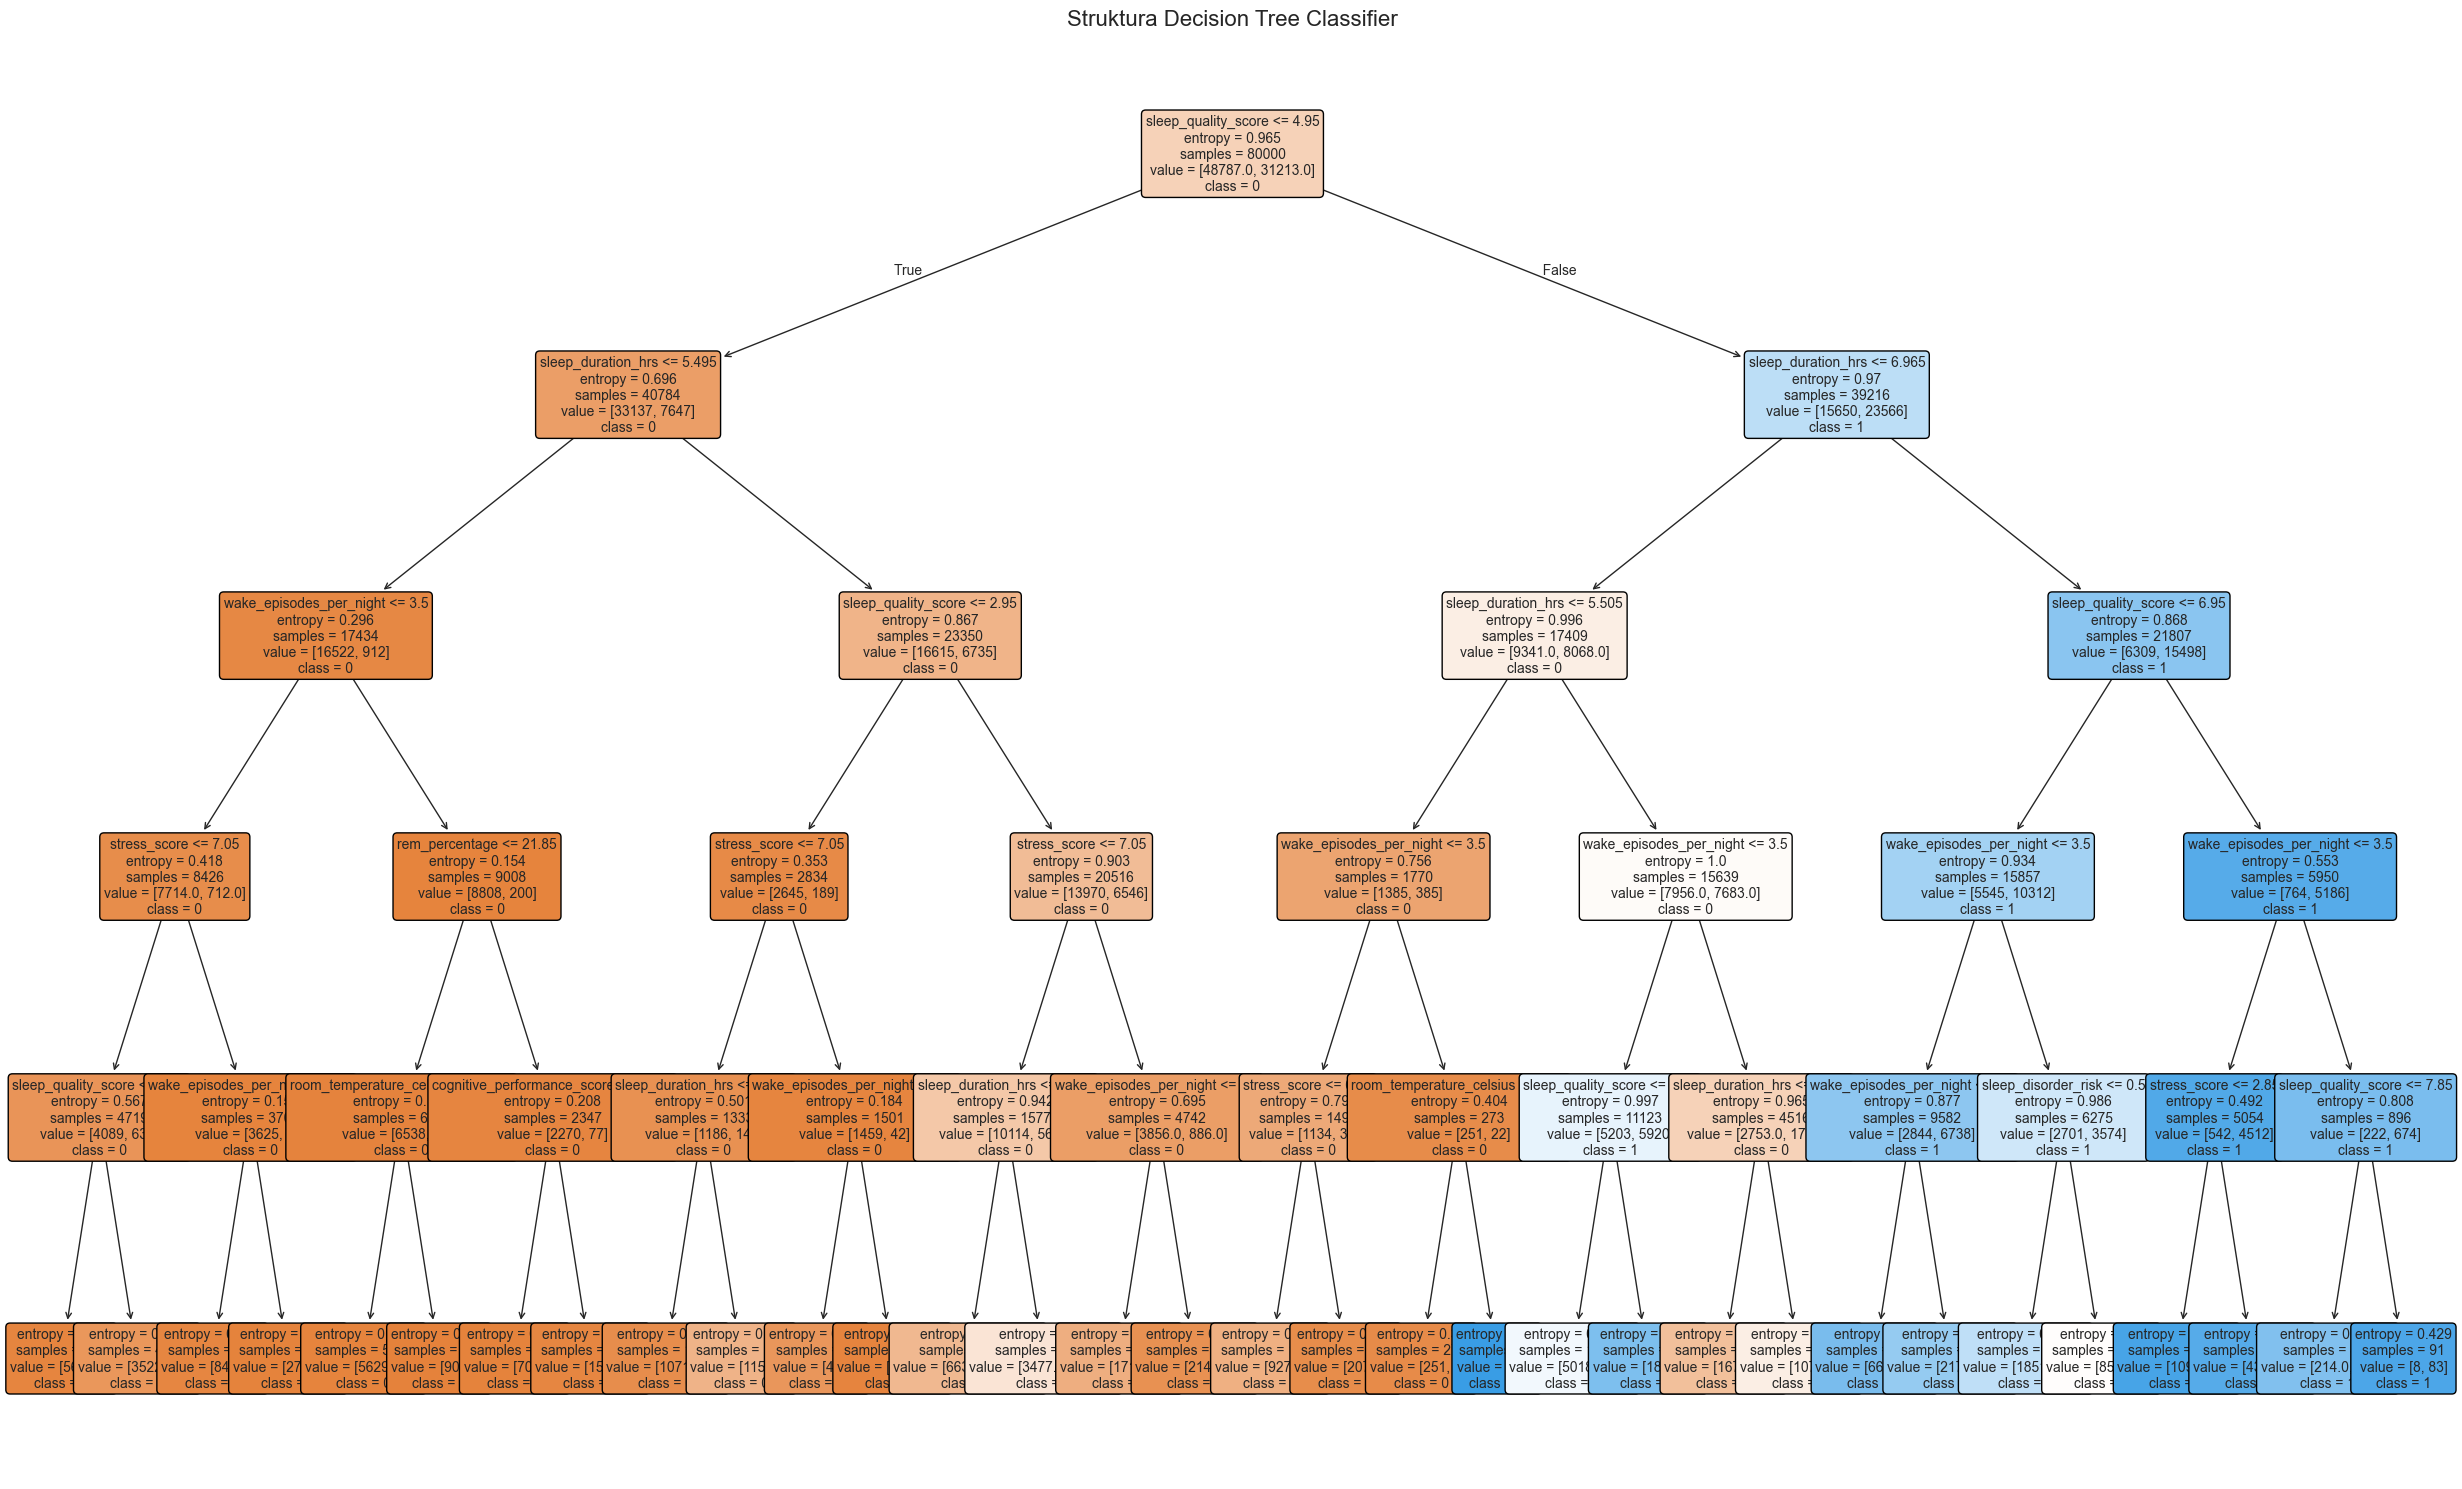

In [13]:
plt.figure(figsize=(25, 15))
plot_tree(dt_classifier,
          feature_names=X_train.columns.tolist(),
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Struktura Decision Tree Classifier', fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
tree_rules = export_text(dt_classifier, feature_names=X_train.columns.tolist())
print(tree_rules)

|--- sleep_quality_score <= 4.95
|   |--- sleep_duration_hrs <= 5.49
|   |   |--- wake_episodes_per_night <= 3.50
|   |   |   |--- stress_score <= 7.05
|   |   |   |   |--- sleep_quality_score <= 2.95
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- sleep_quality_score >  2.95
|   |   |   |   |   |--- class: 0
|   |   |   |--- stress_score >  7.05
|   |   |   |   |--- wake_episodes_per_night <= 1.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- wake_episodes_per_night >  1.50
|   |   |   |   |   |--- class: 0
|   |   |--- wake_episodes_per_night >  3.50
|   |   |   |--- rem_percentage <= 21.85
|   |   |   |   |--- room_temperature_celsius <= 23.85
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- room_temperature_celsius >  23.85
|   |   |   |   |   |--- class: 0
|   |   |   |--- rem_percentage >  21.85
|   |   |   |   |--- cognitive_performance_score <= 36.05
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- cognitive_performance_score >  36.05
|   |   |   |  

## Porównanie z listą 1

In [15]:
print("if quality > 5.45: \n\tif duration < 5.5: \n\t\treturn 0 \n\tif stress > 7.0:\n\t\treturn 0\n\tif latency > 40:\n\t\treturn 0\n\tif (not is_mental_healthy) and stress > 5.5:\n\t\treturn 0\n\tif is_weekday and wakes > 4:\n\t\treturn 0\n\tif is_evening and duration < 6.5:\n\t\treturn 0\n\treturn 1\nelse:\n\tif duration < \n\t\treturn 0\n\tif is_weekday and wakes > 5:\n\t\treturn 0\n\treturn 1")

if quality > 5.45: 
	if duration < 5.5: 
		return 0 
	if stress > 7.0:
		return 0
	if latency > 40:
		return 0
	if (not is_mental_healthy) and stress > 5.5:
		return 0
	if is_weekday and wakes > 4:
		return 0
	if is_evening and duration < 6.5:
		return 0
	return 1
else:
	if duration < 
		return 0
	if is_weekday and wakes > 5:
		return 0
	return 1


## Obliczanie entropii i information gain

In [16]:
def entropy(y):
    y = np.asarray(y)
    if y.size == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()

    # dodaje 10^-12, aby uniknąć log(0)
    return -np.sum(probs * np.log2(probs + 1e-12))

def information_gain(parent_y, left_y, right_y):
    n = len(parent_y)
    if n == 0:
        return 0.0
    n_left = len(left_y)
    n_right = len(right_y)
    if n_left == 0 or n_right == 0:
        return 0.0

    h_parent = entropy(parent_y)
    h_left = entropy(left_y)
    h_right = entropy(right_y)

    ig = h_parent - (n_left / n) * h_left - (n_right / n) * h_right
    return ig

In [17]:
tree = dt_classifier.tree_
node_count = tree.node_count
feature_indices = tree.feature  # -2 dla liści, >=0 dla węzłów
thresholds = tree.threshold
n_node_samples = tree.n_node_samples
total_samples = n_node_samples[0]

# Pobrać ścieżkę decyzji dla każdej próbki treningowej
decision_path = dt_classifier.decision_path(X_train)
decision_path_arr = decision_path.toarray()

feature_importance_manual = {feat: 0.0 for feat in X_train.columns}

for node_id in range(node_count):
    feature_id = feature_indices[node_id]

    if feature_id < 0:
        continue

    feature_name = X_train.columns[feature_id]

    samples_at_node = np.where(decision_path_arr[:, node_id])[0]

    if len(samples_at_node) == 0:
        continue

    parent_y = np.array(y_train)[samples_at_node]

    # Pobrać próg podziału
    threshold = thresholds[node_id]

    # Wykonać podział
    feature_values = X_train.iloc[samples_at_node, feature_id].values
    left_mask = feature_values <= threshold
    left_y, right_y = parent_y[left_mask], parent_y[~left_mask]

    ig_node = information_gain(parent_y, left_y, right_y)

    # Obliczyć ważony wkład (weighted impurity decrease)
    weight = len(samples_at_node) / total_samples
    weighted_ig = weight * ig_node

    feature_importance_manual[feature_name] += weighted_ig

comparison_df = pd.DataFrame({
    'Feature': list(X_train.columns),
    'sklearn_importance': dt_classifier.feature_importances_,
    'manual_importance': [feature_importance_manual[f] for f in X_train.columns]
})
comparison_df = comparison_df.sort_values('sklearn_importance', ascending=False)

print("\nPorównanie importances sklearn vs. ręczne obliczenie:\n")
print(comparison_df.to_string(index=False))


Porównanie importances sklearn vs. ręczne obliczenie:

                    Feature  sklearn_importance  manual_importance
        sleep_quality_score            0.631041           0.155628
         sleep_duration_hrs            0.276701           0.068240
    wake_episodes_per_night            0.048881           0.012055
               stress_score            0.039903           0.009841
        sleep_disorder_risk            0.001830           0.000451
   room_temperature_celsius            0.000686           0.000169
             rem_percentage            0.000554           0.000137
cognitive_performance_score            0.000405           0.000100
                 occupation            0.000000           0.000000
      deep_sleep_percentage            0.000000           0.000000
                    country            0.000000           0.000000
                        bmi            0.000000           0.000000
                     gender            0.000000           0.000000
      

#### Wnioski
Z porównania własnych obliczeń z modelem sklearn widać, że obie metody są zgodne co do kolejności najbardziej wpływowych cech. Brak importance dla części cech wynika z narzuconego rozmiaru drzewa.\

Dla wysokości drzewa = 5:
- Najważniejszą cechą jest `sleep_quality_score`.\
- Najmniej ważną cechą jest `cognitive_performance_score`.\
- Wszystkie cechy z wartością importance = 0 nie są ważne w drzewie.

## Wybór cech do analizy

In [18]:
sorted_features = comparison_df.sort_values('sklearn_importance', ascending=False).reset_index(drop=True)
top_feature = sorted_features.loc[0, 'Feature']
top_importance = sorted_features.loc[0, 'sklearn_importance']

bottom_feature = top_feature # temp assigment
bottom_importance = top_importance

bottom_found = False
i = len(sorted_features) - 1
while not bottom_found:
    if sorted_features.loc[i, 'sklearn_importance'] != 0.0:
        bottom_feature = sorted_features.loc[i, 'Feature']
        bottom_importance = sorted_features.loc[i, 'sklearn_importance']
        bottom_found = True
    else:
        i -= 1

print(f"\nNajważniejsza cecha: '{top_feature}'  -  importance = {top_importance:.6f}")
print(f"Najmniej ważna cecha: '{bottom_feature}'  -  importance = {bottom_importance:.6f}")


Najważniejsza cecha: 'sleep_quality_score'  -  importance = 0.631041
Najmniej ważna cecha: 'cognitive_performance_score'  -  importance = 0.000405


## Pobieranie progów podziału dla wybranych cech

In [19]:
def get_first_threshold_for_feature(feature_name, feature_indices, thresholds):
    col_index = list(X_train.columns).index(feature_name)
    nodes_using_feature = np.where(feature_indices == col_index)[0]

    if len(nodes_using_feature) == 0:
        return None, None

    first_node = nodes_using_feature[0]
    return thresholds[first_node], first_node

threshold_top, node_top = get_first_threshold_for_feature(top_feature, feature_indices, thresholds)
threshold_bottom, node_bottom = get_first_threshold_for_feature(bottom_feature, feature_indices, thresholds)

print(f"\nCecha '{top_feature}':")
if threshold_top is not None:
    print(f"  - Próg z drzewa (węzeł {node_top}): {threshold_top:.6f}")

print(f"\nCecha '{bottom_feature}':")
if threshold_bottom is not None:
    print(f"  - Próg z drzewa (węzeł {node_bottom}): {threshold_bottom:.6f}")


Cecha 'sleep_quality_score':
  - Próg z drzewa (węzeł 0): 4.950000

Cecha 'cognitive_performance_score':
  - Próg z drzewa (węzeł 14): 36.049999


## Porównanie podziału po najważniejszej i najmniej ważnej cesze

In [20]:
def analyze_global_split(feature_name, threshold, y_true):
    feature_values = X_train[feature_name].values
    parent_y = np.array(y_true)

    left_mask = feature_values <= threshold
    left_y, right_y = parent_y[left_mask], parent_y[~left_mask]

    n_left = len(left_y)
    n_right = len(right_y)
    n_total = len(parent_y)

    ig = information_gain(parent_y, left_y, right_y)

    return {
        'feature': feature_name,
        'threshold': threshold,
        'n_left': n_left,
        'n_right': n_right,
        'n_total': n_total,
        'left_proportion': n_left / n_total,
        'right_proportion': n_right / n_total,
        'entropy_parent': entropy(parent_y),
        'entropy_left': entropy(left_y),
        'entropy_right': entropy(right_y),
        'information_gain': ig
    }

split_top = analyze_global_split(top_feature, threshold_top, y_train)
split_bottom = analyze_global_split(bottom_feature, threshold_bottom, y_train)

ratio_ig = split_top['information_gain'] / split_bottom['information_gain'] if split_bottom['information_gain'] > 0 else float('inf')
ratio_importance = top_importance / bottom_importance if bottom_importance > 0 else float('inf')

print(f"\n{'Metryka':<25} {'Najlepsza cecha':<30} {'Najgorsza cecha':<30}")
print("-" * 85)
print(f"{'Nazwa cechy':<25} {split_top['feature']:<30} {split_bottom['feature']:<30}")
print(f"{'Próg podziału':<25} {split_top['threshold']:<30.6f} {split_bottom['threshold']:<30.6f}")
print(f"{'Lewe - ilość':<25} {split_top['n_left']:<30} {split_bottom['n_left']:<30}")
print(f"{'Prawe - ilość':<25} {split_top['n_right']:<30} {split_bottom['n_right']:<30}")
print(f"{'Lewe - proporcja':<25} {split_top['left_proportion']:<30.4f} {split_bottom['left_proportion']:<30.4f}")
print(f"{'Prawe - proporcja':<25} {split_top['right_proportion']:<30.4f} {split_bottom['right_proportion']:<30.4f}")
print(f"{'Entropia rodzica':<25} {split_top['entropy_parent']:<30.6f} {split_bottom['entropy_parent']:<30.6f}")
print(f"{'Entropia lewego':<25} {split_top['entropy_left']:<30.6f} {split_bottom['entropy_left']:<30.6f}")
print(f"{'Entropia prawego':<25} {split_top['entropy_right']:<30.6f} {split_bottom['entropy_right']:<30.6f}")
print(f"{'Information Gain':<25} {split_top['information_gain']:<30.6f} {split_bottom['information_gain']:<30.6f}")

print(f"\nStosunek Feature Importance:")
print(f"  TOP / BOTTOM = {top_importance:.6f} / {bottom_importance:.6f} = {ratio_importance:.2f}x")

print(f"\nStosunek Information Gain:")
print(f"  TOP / BOTTOM = {split_top['information_gain']:.6f} / {split_bottom['information_gain']:.6f} = {ratio_ig:.2f}x")


Metryka                   Najlepsza cecha                Najgorsza cecha               
-------------------------------------------------------------------------------------
Nazwa cechy               sleep_quality_score            cognitive_performance_score   
Próg podziału             4.950000                       36.049999                     
Lewe - ilość              40784                          12598                         
Prawe - ilość             39216                          67402                         
Lewe - proporcja          0.5098                         0.1575                        
Prawe - proporcja         0.4902                         0.8425                        
Entropia rodzica          0.964904                       0.964904                      
Entropia lewego           0.696212                       0.377121                      
Entropia prawego          0.970405                       0.992611                      
Information Gain          0.13428

#### Wnioski
#### Porównanie
Lewe / Prawe - ilość i proporcja:
- Cecha `sleep_quality_score` daje praktycznie zbalansowany podział i dzieli dane na dwa zbiory podobnej wielkości.
- Cecha `coginitive_performance_score` daje bardzo niesymetryczny podział. Takie nierówne rozdzielenie prowadzi do mniejszych korzyści informacyjnych z tego podziału.

Entropia lewego i prawego pod drzewa:
- `sleep_quality_score` - podział znacząco oczyszcza lewą gałąź, prawa zostaje zanieczyszczona.
- `coginitive_performance_score` - lewa, mała gałąź jest bardzo czysta, ale prawa jest jeszcze bardziej zanieczyszczona niż przed podziałem.

Information Gain:
- Mimo że `cognitive_performance_score` dawało bardzo czystą lewą gałąź, jego lewa gałąź jest bardzo mała, przez co ważony efekt redukcji entropii jest mniejszy. W rezultacie `sleep_quality_score` daje większy ogólny zysk informacyjny, bo łącznie z większym rozmiarem lewej gałęzi powoduje większą redukcję niepewności w całym zbiorze.

# Problem regresji
#### Przewidywanie zmiennej cognitive_performance_score na podstawie pozostałych cech metodą Least Squares i Gradient Descent


## Przygotowane dancyh


In [21]:
target_reg = 'cognitive_performance_score'

y_reg = df_encoded[target_reg].values
X_reg = df_encoded.drop(columns=[target_reg])

if VERBOSE:
    print(f"Rozmiar danych do regresji: {X_reg.shape[0]} wierszy x {X_reg.shape[1]} kolumn")
    print(f"\nZmienna docelowa: {target_reg}")
    print(f"Zakres wartości: [{y_reg.min():.2f}, {y_reg.max():.2f}]")
    print(f"Średnia: {y_reg.mean():.2f}, Std Dev: {y_reg.std():.2f}")

In [22]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=32
)

## Regresja liniowa dla nieustandaryzowanych danych

In [23]:
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_reg, y_train_reg)

intercept_sklearn_unscaled = model_sklearn.intercept_
coef_sklearn_unscaled = model_sklearn.coef_

print(f"Intercept: {intercept_sklearn_unscaled:.6f}")
print(f"Wagi: {coef_sklearn_unscaled[:].round(5)}")

Intercept: -33.982846
Wagi: [ 0.01508 -0.04332  0.04263  0.17485  0.00396  1.66834  8.26124  1.09915
  0.63988  0.1233   0.41177 -0.00976 -2.10279  0.00285  7.95058 -0.00001
 -0.0033  -0.75439  0.07694 -0.11433  0.54784  0.0011   0.16603 -2.79189
  0.02574 -0.00672  0.01846  3.13815 -5.05483  0.58186]


## Standaryzacja danych

In [24]:
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.fit_transform(X_test_reg)

# X_train_reg_scaled = X_train_reg
# X_test_reg_scaled = X_test_reg

scaled_df = pd.DataFrame(X_train_reg_scaled, columns=X_train_reg.columns)

print(f"\nPo standaryzacji:")
scaled_df.describe().round(3)


Po standaryzacji:


,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,sleep_disorder_risk,felt_rested
count,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,...,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.00
mean,0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,...,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.00
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.00
min,-1.512,-0.963,-1.739,-2.298,-1.586,-2.683,-2.570,-3.000,-3.591,-2.480,...,-2.112,-2.990,-1.131,-0.305,-1.909,-2.795,-1.344,-0.632,-0.775,-0.80
25%,-0.788,-0.963,-0.885,-0.689,-0.732,-0.700,-0.711,-0.655,-0.673,-0.767,...,-0.313,-0.633,-1.131,-0.305,-0.702,-0.674,-0.447,-0.632,-0.775,-0.80
50%,-0.155,-0.963,-0.031,0.004,-0.092,-0.050,0.020,0.019,0.009,-0.108,...,0.587,0.060,0.884,-0.305,-0.012,-0.000,-0.447,-0.632,-0.775,-0.80
75%,0.660,0.896,0.824,0.675,1.189,0.664,0.750,0.693,0.692,0.682,...,0.587,0.614,0.884,-0.305,0.677,0.686,0.449,1.582,0.470,1.25
max,3.103,2.755,1.393,4.183,1.403,3.195,3.406,2.862,2.292,5.031,...,0.587,4.218,0.884,3.275,2.574,2.287,1.346,1.582,2.962,1.25


## METODA 1: Rozwiązanie analityczne Least Squares


In [25]:
def fit_linear_regression_analytical(X, y):
    n_samples, n_features = X.shape

    # Dodaj kolumnę jedynek dla intercept
    X_with_bias = np.column_stack([np.ones(n_samples), X])

    # Oblicz macierz pseudoodwrotną
    # w = inv(X^T X) @ X^T @ y
    XtX = X_with_bias.T @ X_with_bias
    XtX_inv = np.linalg.inv(XtX)
    Xty = X_with_bias.T @ y

    w = XtX_inv @ Xty

    return w  # w[0] to bias, w[1:] to coefficients

def predict_linear(X, w):
    """Przyjmuje wartości X i wagi w tych wartości"""
    n_samples = X.shape[0]
    X_with_bias = np.column_stack([np.ones(n_samples), X])
    return X_with_bias @ w

In [26]:
print("Trenowanie modelu - metoda analityczna")
w_analytical = fit_linear_regression_analytical(X_train_reg_scaled, y_train_reg)

intercept_analytical = w_analytical[0]
coef_analytical = w_analytical[1:]

print(f"Intercept: {intercept_analytical:.6f}")
print(f"Wagi: {coef_analytical[:].round(5)}")

Trenowanie modelu - metoda analityczna
Intercept: 59.220159
Wagi: [ 0.16671 -0.0233   0.14971  0.7824   0.01855  2.12872 12.44128  3.7505
  2.71927  0.93565  0.79021 -0.6773  -2.21914  0.12686  3.95626 -0.03797
 -0.07057 -1.22267  0.26796 -0.0974   0.60897  0.0079   0.08239 -0.7798
  0.07466 -0.00529  0.02059  1.4175  -4.05797  0.28381]


In [27]:
y_train_pred_analytical = predict_linear(X_train_reg_scaled, w_analytical)
y_test_pred_analytical = predict_linear(X_test_reg_scaled, w_analytical)

mse_train_analytical = mse(y_train_reg, y_train_pred_analytical)
mse_test_analytical = mse(y_test_reg, y_test_pred_analytical)
mae_train_analytical = mae(y_train_reg, y_train_pred_analytical)
mae_test_analytical = mae(y_test_reg, y_test_pred_analytical)

print(f"\nMetoda Analityczna:")
print(f"  Train MSE: {mse_train_analytical:.6f},  MAE: {mae_train_analytical:.6f}")
print(f"  Test MSE:  {mse_test_analytical:.6f},  MAE: {mae_test_analytical:.6f}")


Metoda Analityczna:
  Train MSE: 50.115163,  MAE: 5.600072
  Test MSE:  49.662122,  MAE: 5.564931


## METODA 2: Gradient Descent


In [28]:
def fit_linear_regression_gd(X, y, learning_rate=0.01, epochs=2000, verbose=False):
    n_samples, n_features = X.shape

    w = np.zeros(n_features + 1)

    # Dodaj bias do X
    X_with_bias = np.column_stack([np.ones(n_samples), X])

    history_loss = []

    for epoch in range(epochs):
        y_pred = X_with_bias @ w
        error = y_pred - y

        gradient = (2.0 / n_samples) * (X_with_bias.T @ error)

        w = w - learning_rate * gradient
        loss = mse(y, y_pred)
        history_loss.append(loss)

        if verbose and (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}: MSE = {loss:.6f}")

    return w, history_loss

print("Trenowanie modelu - Gradient Descent")

learning_rates = [0.001, 0.01, 0.1]
gd_results = {}

for lr in learning_rates:
    print(f"Learning rate = {lr}")
    w_gd, history = fit_linear_regression_gd(
        X_train_reg_scaled, y_train_reg,
        learning_rate=lr, epochs=2000, verbose=False
    )
    gd_results[lr] = {"w": w_gd, "history": history}

    y_train_pred_gd = predict_linear(X_train_reg_scaled, w_gd)
    mse_train_gd = mse(y_train_reg, y_train_pred_gd)
    print(f"  Final Train MSE: {mse_train_gd:.6f}\n")

# Wybierz najlepszy learning rate (najniższe MSE)
best_lr = min(gd_results.keys(),
              key=lambda lr: gd_results[lr]["history"][-1])
w_gradient_descent = gd_results[best_lr]["w"]

print(f"Wybrany learning rate: {best_lr}")

intercept_gd = w_gradient_descent[0]
coef_gd = w_gradient_descent[1:]

print(f"Intercept: {intercept_gd:.6f}")
print(f"Wagi (pierwsze 5): {coef_gd[:].round(5)}")

Trenowanie modelu - Gradient Descent
Learning rate = 0.001
  Final Train MSE: 54.528234

Learning rate = 0.01
  Final Train MSE: 50.115172

Learning rate = 0.1
  Final Train MSE: 50.115163

Wybrany learning rate: 0.1
Intercept: 59.220159
Wagi (pierwsze 5): [ 0.16671 -0.0233   0.14971  0.7824   0.01855  2.12872 12.44128  3.7505
  2.71927  0.93565  0.79021 -0.6773  -2.21914  0.12686  3.95626 -0.03797
 -0.07057 -1.22267  0.26796 -0.0974   0.60897  0.0079   0.08239 -0.7798
  0.07466 -0.00529  0.02059  1.4175  -4.05797  0.28381]


In [29]:
y_train_pred_gd = predict_linear(X_train_reg_scaled, w_gradient_descent)
y_test_pred_gd = predict_linear(X_test_reg_scaled, w_gradient_descent)

mse_train_gd = mse(y_train_reg, y_train_pred_gd)
mse_test_gd = mse(y_test_reg, y_test_pred_gd)
mae_train_gd = mae(y_train_reg, y_train_pred_gd)
mae_test_gd = mae(y_test_reg, y_test_pred_gd)

print(f"Gradient Descent (lr={best_lr}):")
print(f"  Train MSE: {mse_train_gd:.6f},  MAE: {mae_train_gd:.6f}")
print(f"  Test MSE:  {mse_test_gd:.6f},  MAE: {mae_test_gd:.6f}")


Gradient Descent (lr=0.1):
  Train MSE: 50.115163,  MAE: 5.600072
  Test MSE:  49.662122,  MAE: 5.564931


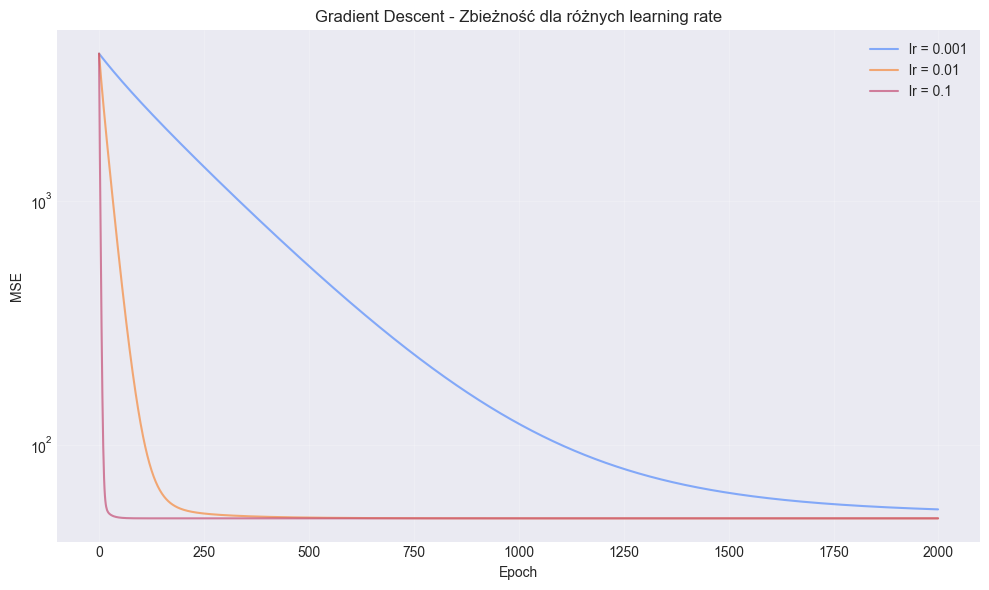

In [30]:
# Wizualizacja historii trenowania dla różnych learning rates
fig, ax = plt.subplots(figsize=(10, 6))

for lr in learning_rates:
    ax.plot(gd_results[lr]["history"], label=f"lr = {lr}", alpha=0.7)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Gradient Descent - Zbieżność dla różnych learning rate")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Opis wykresu zbieżności dla różnych learning rate
Wykres przedstawia wpływ wartości współczynnika uczenia na szybkość i charakter zbieżności algorytmu Gradient Descent, mierzonej za pomocą MSE w kolejnych epokach.

Dla najmniejszej wartości współczynnika (lr = 0.001) obserwowana jest bardzo powolna, lecz stabilna redukcja błędu, co oznacza, że algorytm wykonuje niewielkie kroki i potrzebuje wielu iteracji, aby zbliżyć się do minimum.

Z kolei dla lr = 0.01 proces uczenia przebiega znacznie szybciej - błąd gwałtownie maleje w początkowej fazie, a następnie stabilizuje się na niskim poziomie, co wskazuje na korzystny kompromis między szybkością a stabilnością zbieżności.

Największa z analizowanych wartości (lr = 0.1) prowadzi do bardzo szybkiego spadku błędu już w pierwszych iteracjach, co świadczy o dynamicznym zbliżaniu się do minimum funkcji kosztu, przy czym w tym przypadku nie występują oznaki niestabilności. Ostatecznie wszystkie krzywe osiągają zbliżony poziom błędu końcowego, co sugeruje, że niezależnie od wartości współczynnika uczenia algorytm znajduje podobne rozwiązanie, jednak różni się znacząco efektywnością dochodzenia do tego minimum.

## METODA 3: Sklearn linear regression

In [31]:
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_reg_scaled, y_train_reg)

intercept_sklearn_scaled = model_sklearn.intercept_
coef_sklearn_scaled = model_sklearn.coef_

print(f"Intercept: {intercept_sklearn_scaled:.6f}")
print(f"Wagi: {coef_sklearn_scaled[:].round(5)}")

Intercept: 59.220159
Wagi: [ 0.16671 -0.0233   0.14971  0.7824   0.01855  2.12872 12.44128  3.7505
  2.71927  0.93565  0.79021 -0.6773  -2.21914  0.12686  3.95626 -0.03797
 -0.07057 -1.22267  0.26796 -0.0974   0.60897  0.0079   0.08239 -0.7798
  0.07466 -0.00529  0.02059  1.4175  -4.05797  0.28381]


In [32]:
y_train_pred_sklearn = model_sklearn.predict(X_train_reg_scaled)
y_test_pred_sklearn = model_sklearn.predict(X_test_reg_scaled)

mse_train_sklearn = mse(y_train_reg, y_train_pred_sklearn)
mse_test_sklearn = mse(y_test_reg, y_test_pred_sklearn)
mae_train_sklearn = mae(y_train_reg, y_train_pred_sklearn)
mae_test_sklearn = mae(y_test_reg, y_test_pred_sklearn)

print(f"Sklearn Linear Regression:")
print(f"  Train MSE: {mse_train_sklearn:.6f},  MAE: {mae_train_sklearn:.6f}")
print(f"  Test MSE:  {mse_test_sklearn:.6f},  MAE: {mae_test_sklearn:.6f}")

Sklearn Linear Regression:
  Train MSE: 50.115163,  MAE: 5.600072
  Test MSE:  49.662122,  MAE: 5.564931


## Porównanie wszystkich metod

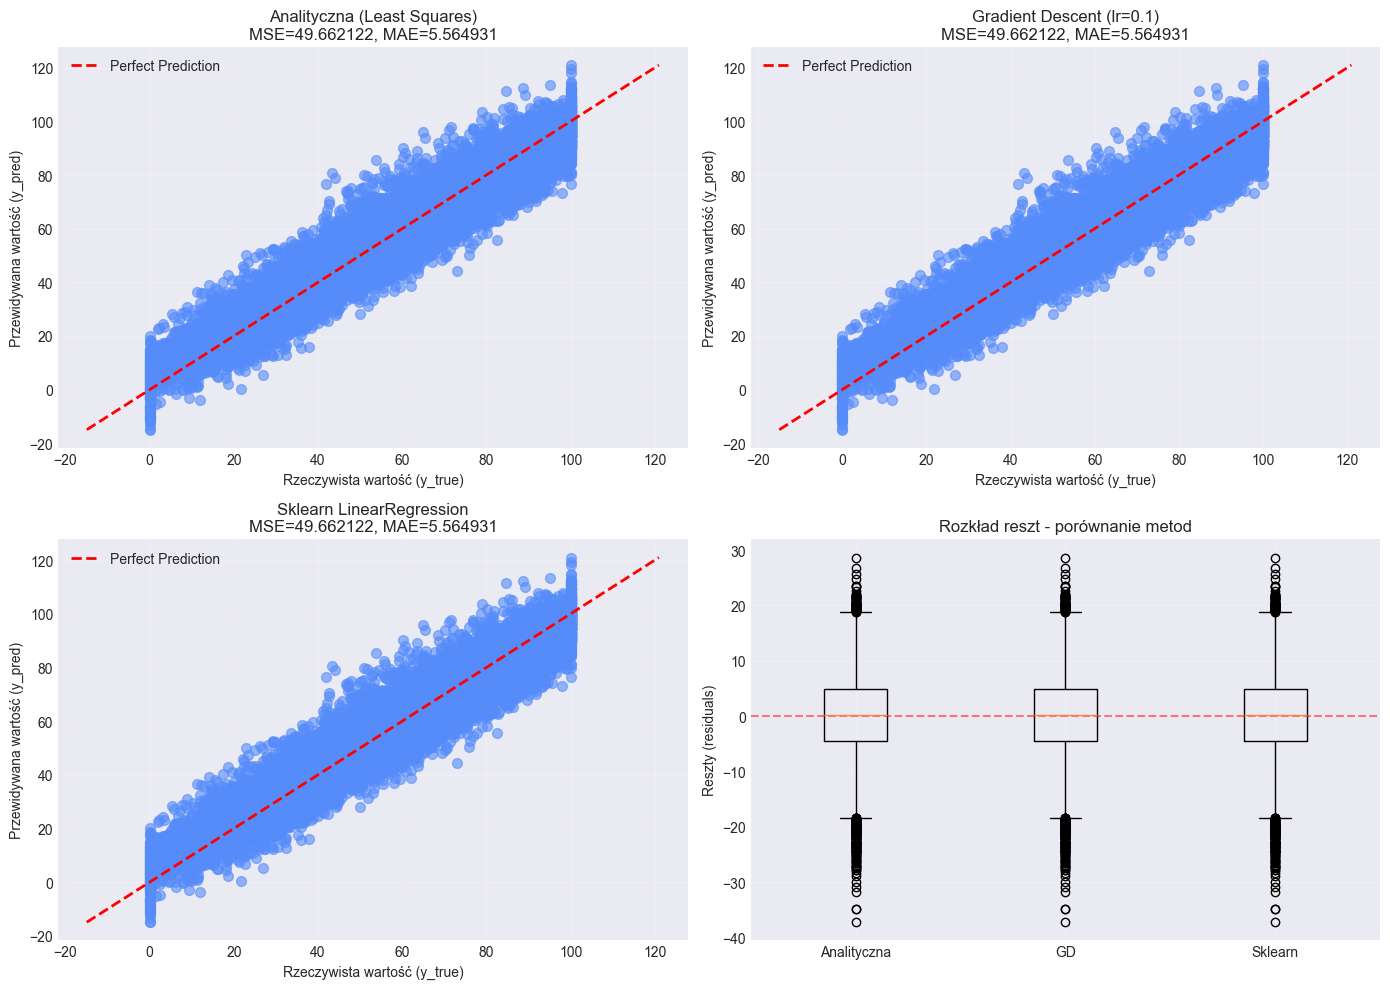

PORÓWNANIE BŁĘDÓW NA ZBIORZE TESTOWYM:

                     Metoda  Train MSE  Test MSE  Train MAE  Test MAE
Analityczna - Least Squares  50.115163 49.662122   5.600072  5.564931
  Gradient Descent (lr=0.1)  50.115163 49.662122   5.600072  5.564931
   Sklearn LinearRegression  50.115163 49.662122   5.600072  5.564931


In [33]:
comparison_results = pd.DataFrame({
    'Metoda': ['Analityczna - Least Squares', f'Gradient Descent (lr={best_lr})', 'Sklearn LinearRegression'],
    'Train MSE': [mse_train_analytical, mse_train_gd, mse_train_sklearn],
    'Test MSE': [mse_test_analytical, mse_test_gd, mse_test_sklearn],
    'Train MAE': [mae_train_analytical, mae_train_gd, mae_train_sklearn],
    'Test MAE': [mae_test_analytical, mae_test_gd, mae_test_sklearn]
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = [
    ("Analityczna (Least Squares)", y_test_pred_analytical),
    (f"Gradient Descent (lr={best_lr})", y_test_pred_gd),
    ("Sklearn LinearRegression", y_test_pred_sklearn)
]

for idx, (method_name, y_pred) in enumerate(methods):
    ax = axes[idx // 2, idx % 2]

    ax.scatter(y_test_reg, y_pred, alpha=0.6, s=50)

    # Idealna prosta y=x
    min_val = min(y_test_reg.min(), y_pred.min())
    max_val = max(y_test_reg.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction', linewidth=2)

    test_mse = mse(y_test_reg, y_pred)
    test_mae = mae(y_test_reg, y_pred)

    ax.set_xlabel("Rzeczywista wartość (y_true)")
    ax.set_ylabel("Przewidywana wartość (y_pred)")
    ax.set_title(f"{method_name}\nMSE={test_mse:.6f}, MAE={test_mae:.6f}")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Czwarty subplot: porównanie reszt
ax = axes[1, 1]

residuals_analytical = y_test_reg - y_test_pred_analytical
residuals_gd = y_test_reg - y_test_pred_gd
residuals_sklearn = y_test_reg - y_test_pred_sklearn

ax.boxplot([residuals_analytical, residuals_gd, residuals_sklearn],
           tick_labels=['Analityczna', 'GD', 'Sklearn'])
ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_ylabel("Reszty (residuals)")
ax.set_title("Rozkład reszt - porównanie metod")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("PORÓWNANIE BŁĘDÓW NA ZBIORZE TESTOWYM:\n")
print(comparison_results.to_string(index=False))

#### Wnioski z tabeli metryk i wykresów predykcji modeli
Porównanie trzech podejść do regresji liniowej wykazuje pełną zbieżność wyników. Tak niskie różnice (poniżej 10^-10) potwierdzają, że wszystkie trzy implementacje są matematycznie równoważne i poprawnie zbiegły do globalnego minimum.

Wybór metody (analityczna, GD, sklearn) nie jest zatem kluczowy z punktu widzenia ostatecznej jakości modelu. Różnice mogą wytwarzać się w szybkości zbieżności (dla Gradient Descent) lub stabilności numerycznej (dla Least Squares), ale na finalnych wynikach się nie odbijają.

## Porównanie wag

In [34]:
print(f"{'Cecha':<30} {'Analityczna':<20} {'Gradient Descent':<20} {'Sklearn':<20}")
print("-" * 90)

feature_names = X_train_reg.columns.tolist()
for i in range(min(10, len(feature_names))):
    print(f"{feature_names[i]:<30} {coef_analytical[i]:<20.10f} {coef_gd[i]:<20.10f} {coef_sklearn_scaled[i]:<20.10f}")


Cecha                          Analityczna          Gradient Descent     Sklearn             
------------------------------------------------------------------------------------------
age                            0.1667086457         0.1667086457         0.1667086457        
gender                         -0.0233040399        -0.0233040399        -0.0233040399       
occupation                     0.1497077608         0.1497077608         0.1497077608        
bmi                            0.7823950368         0.7823950368         0.7823950368        
country                        0.0185505944         0.0185505944         0.0185505944        
sleep_duration_hrs             2.1287246162         2.1287246162         2.1287246162        
sleep_quality_score            12.4412825860        12.4412825860        12.4412825860       
rem_percentage                 3.7505002306         3.7505002306         3.7505002306        
deep_sleep_percentage          2.7192688178         2.719268817

#### Opis uzyskanych wag
Wyniki pokazują pełną zgodność trzech podejść, ponieważ wszystkie zwracają identyczne współczynniki. To oznacza, że model liniowy został poprawnie dopasowany i niezależnie od metody optymalizacji prowadzi do tego samego rozwiązania.

Najsilniej dodatnio na zmienną docelową wpływa `sleep_quality_score`. Współczynnik tej cechy jest zdecydowanie największy, co sugeruje, że ma kluczowe znaczenie dla przewidywanego wyniku. Wzrost wyniku jakości spania o 1 powduje średni wzrost wartości `cognitive_performance_score` o 12.44, przy zachowaniu innych parametrów bez zmian.

Współczynnik przy `gender` jest lekko ujemny, ale jego wartość jest bardzo mała, więc wpływ tej cechy na wynik jest marginalny. Podobnie `country` ma niewielkie znaczenie. Oznacza to, że model opiera swoje predykcje głównie na cechach opisujących sam sen, a nie na zmiennych demograficznych.

## Porównanie wag regresji między danymi przed i po skalowaniu

In [35]:
print(f"{'Cecha':<30} {'Scaled':<20} {'Unscaled':<20}")
print("-" * 90)

feature_names = X_train_reg.columns.tolist()
for i in range(min(10, len(feature_names))):
    print(f"{feature_names[i]:<30} {coef_sklearn_scaled[i]:<20.5f} {coef_sklearn_unscaled[i]:<20.5f}")

Cecha                          Scaled               Unscaled            
------------------------------------------------------------------------------------------
age                            0.16671              0.01508             
gender                         -0.02330             -0.04332            
occupation                     0.14971              0.04263             
bmi                            0.78240              0.17485             
country                        0.01855              0.00396             
sleep_duration_hrs             2.12872              1.66834             
sleep_quality_score            12.44128             8.26124             
rem_percentage                 3.75050              1.09915             
deep_sleep_percentage          2.71927              0.63988             
sleep_latency_mins             0.93565              0.12330             


#### Wnioski
Porównanie wag regresji przed i po skalowaniu pokazuje przede wszystkim, że sam model zachowuje ten sam kierunek wpływu cech, ale zmienia się skala współczynników. Po standaryzacji wszystkie zmienne są sprowadzone do porównywalnego poziomu, dlatego współczynniki są bardziej uczciwie zestawione między sobą i lepiej odzwierciedlają wpływ cech.

Po skalowaniu współczynniki są większe numerycznie dla wielu cech, ponieważ każda zmienna została przekształcona do tej samej skali odchylenia standardowego. Dzięki temu można powiedzieć, że wzrost o jedno odchylenie standardowe w sleep_quality_score ma znacznie silniejszy wpływ na wynik niż analogiczny wzrost w cechach demograficznych, takich jak age, country czy gender.

Skalowanie nie zmienia sensu modelu, tylko poprawia porównywalność wag i stabilność interpretacji, a główne znaczenie w przewidywaniu nadal mają cechy opisujące jakość i strukturę snu.

# Wymuszanie skrajnych stanów (Underfitting vs Overfitting)

## Krzywa złożoności dla drzewa (Bias-Variance)

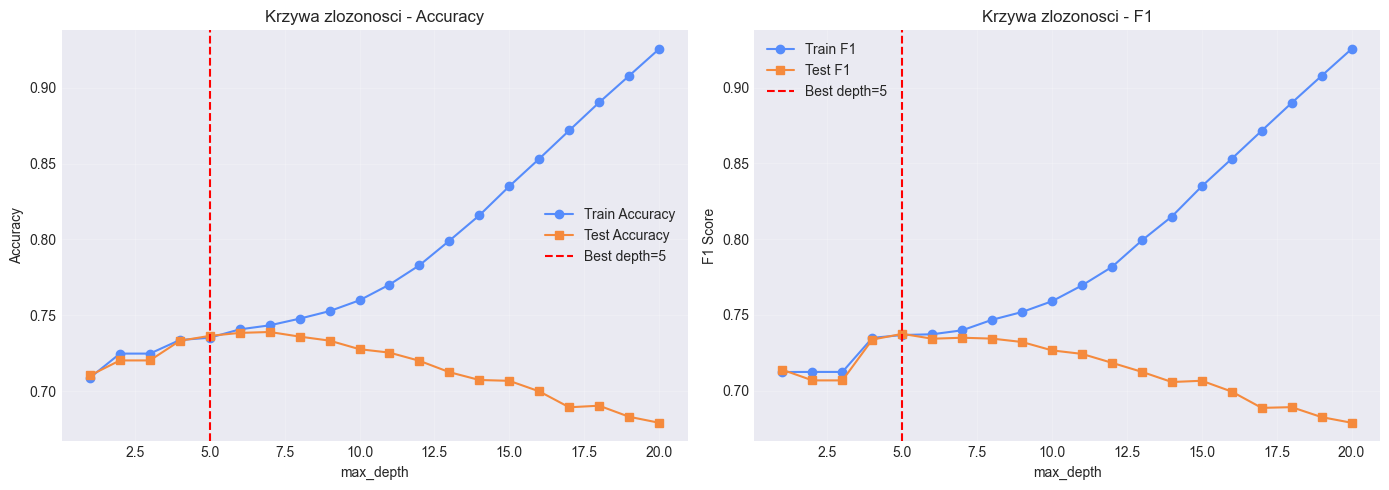

In [37]:
depth_values = range(1, 21)
train_acc_curve, test_acc_curve = [], []
train_f1_curve, test_f1_curve = [], []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=13)
    model.fit(X_train, y_train)
    y_train_pred_local = model.predict(X_train)
    y_test_pred_local = model.predict(X_test)

    train_acc_curve.append(accuracy_score(y_train, y_train_pred_local))
    test_acc_curve.append(accuracy_score(y_test, y_test_pred_local))
    train_f1_curve.append(f1_score(y_train, y_train_pred_local, average='weighted', zero_division=0))
    test_f1_curve.append(f1_score(y_test, y_test_pred_local, average='weighted', zero_division=0))

best_depth_idx = int(np.argmax(test_f1_curve))
best_depth = list(depth_values)[best_depth_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(depth_values, train_acc_curve, marker='o', label='Train Accuracy')
axes[0].plot(depth_values, test_acc_curve, marker='s', label='Test Accuracy')
axes[0].axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Krzywa zlozonosci - Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(depth_values, train_f1_curve, marker='o', label='Train F1')
axes[1].plot(depth_values, test_f1_curve, marker='s', label='Test F1')
axes[1].axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Krzywa zlozonosci - F1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Wnioski
Na wykresie strefa High Bias (underfitting) występuje przy niskich wartościach max_depth (ok. 1-3), gdzie zarówno metryki treningowe, jak i testowe są niskie.\
Punkt optymalny znajduje się wokół max_depth = 5, gdzie metryki testowe osiągają maksimum i model najlepiej generalizuje.\
Powyżej tego punktu zaczyna się strefa High Variance (overfitting): metryki treningowe rosną dalej, a metryki testowe spadają.

Wzrost złożoności daje modelowi większą pojemność do odwzorowania sygnału i szumu, więc błąd treningowy maleje. Jednak model, ucząc się przypadkowych odchyleń danych treningowych, traci zdolność uogólniania, co zwiększa wariancję i błąd testowy.

## Wymuszanie skrajnych stanów (Underfitting vs Overfitting) - regresja wielomianowa

In [48]:
# feature_for_poly = X_train_reg.var().sort_values(ascending=False).index[0]
feature_for_poly = 'sleep_quality_score'
feature_idx = list(X_train_reg.columns).index(feature_for_poly)

x_train_raw = X_train_reg[feature_for_poly].to_numpy().reshape(-1, 1)
x_test_raw = X_test_reg[feature_for_poly].to_numpy().reshape(-1, 1)

mean_feature = scaler_reg.mean_[feature_idx]
scale_feature = scaler_reg.scale_[feature_idx]

x_train = (x_train_raw - mean_feature) / scale_feature
x_test = (x_test_raw - mean_feature) / scale_feature

def fit_poly_regression(degree, x_train_local, y_train_local, x_test_local, y_test_local):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(x_train_local)
    X_test_poly = poly.transform(x_test_local)

    model = LinearRegression()
    model.fit(X_train_poly, y_train_local)

    y_train_pred_local = model.predict(X_train_poly)
    y_test_pred_local = model.predict(X_test_poly)

    return {
        "model": model,
        "poly": poly,
        "train_mse": mse(y_train_local, y_train_pred_local),
        "test_mse": mse(y_test_local, y_test_pred_local),
        "train_mae": mae(y_train_local, y_train_pred_local),
        "test_mae": mae(y_test_local, y_test_pred_local),
    }

poly_underfit = fit_poly_regression(1, x_train, y_train_reg, x_test, y_test_reg)
poly_overfit = fit_poly_regression(15, x_train, y_train_reg, x_test, y_test_reg)

poly_under_over = pd.DataFrame([
    {
        "Model": "Underfitting (degree=1)",
        "Train MSE": poly_underfit["train_mse"],
        "Test MSE": poly_underfit["test_mse"],
        "Train MAE": poly_underfit["train_mae"],
        "Test MAE": poly_underfit["test_mae"],
    },
    {
        "Model": "Overfitting (degree=15)",
        "Train MSE": poly_overfit["train_mse"],
        "Test MSE": poly_overfit["test_mse"],
        "Train MAE": poly_overfit["train_mae"],
        "Test MAE": poly_overfit["test_mae"],
    },
])

print("\nPorownanie regresji wielomianowej:")
print(f"Wybrana cecha: {feature_for_poly}")
print(poly_under_over.to_string(index=False))


Porownanie regresji wielomianowej:
Wybrana cecha: sleep_quality_score
                  Model  Train MSE   Test MSE  Train MAE  Test MAE
Underfitting (degree=1) 128.732408 129.709999   9.080432  9.131089
Overfitting (degree=15) 126.719204 127.558418   9.011563  9.055572


## Krzywa złożoności dla regresji wielomianowej (Bias-Variance)

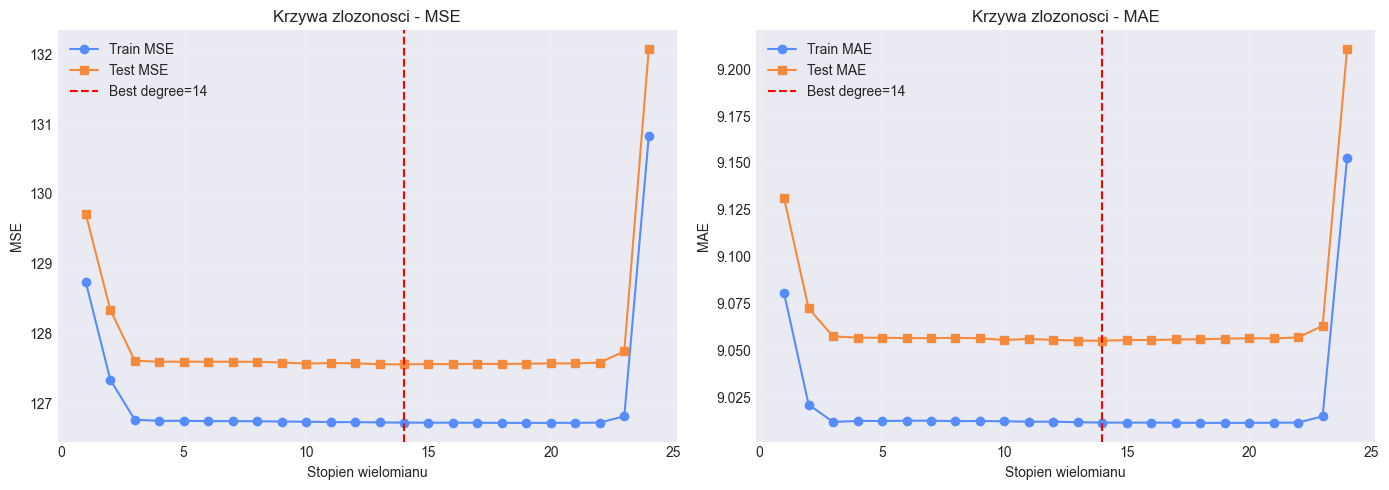

In [49]:
degree_values = range(1, 25)
train_mse_curve, test_mse_curve = [], []
train_mae_curve, test_mae_curve = [], []
poly_models = []

for degree in degree_values:
    result = fit_poly_regression(degree, x_train, y_train_reg, x_test, y_test_reg)
    train_mse_curve.append(result["train_mse"])
    test_mse_curve.append(result["test_mse"])
    train_mae_curve.append(result["train_mae"])
    test_mae_curve.append(result["test_mae"])
    poly_models.append(result)

best_degree_idx = int(np.argmin(test_mse_curve))
best_degree = list(degree_values)[best_degree_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(degree_values, train_mse_curve, marker='o', label='Train MSE')
axes[0].plot(degree_values, test_mse_curve, marker='s', label='Test MSE')
axes[0].axvline(best_degree, color='red', linestyle='--', label=f'Best degree={best_degree}')
axes[0].set_xlabel('Stopien wielomianu')
axes[0].set_ylabel('MSE')
axes[0].set_title('Krzywa zlozonosci - MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(degree_values, train_mae_curve, marker='o', label='Train MAE')
axes[1].plot(degree_values, test_mae_curve, marker='s', label='Test MAE')
axes[1].axvline(best_degree, color='red', linestyle='--', label=f'Best degree={best_degree}')
axes[1].set_xlabel('Stopien wielomianu')
axes[1].set_ylabel('MAE')
axes[1].set_title('Krzywa zlozonosci - MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Wnioski
Wykres nie pokazuje klasycznego stopniowego rozjazdu - zamiast tego przy bardzo wysokich stopniach widać gwałtowny skok MSE/MAE zarówno dla treningu, jak i testu, co wskazuje na problem numeryczny lub niestabilność modelu niż typowe overfittingowe rozjechanie się krzywych.

Bark widocznego overfittingu jest prawdopodobnie spowodowana tym, że ilość danych jest wystarczająco duża względem złożoności modelu lub w danych występuje za mało szumu

## Powtórzenie testu z dodanym szumem

Best degree (min Test MSE): 4
Underfit degree: 1, Overfit degree: 12
Train MSE overfit: 0.0398
Test  MSE overfit: 11.4168


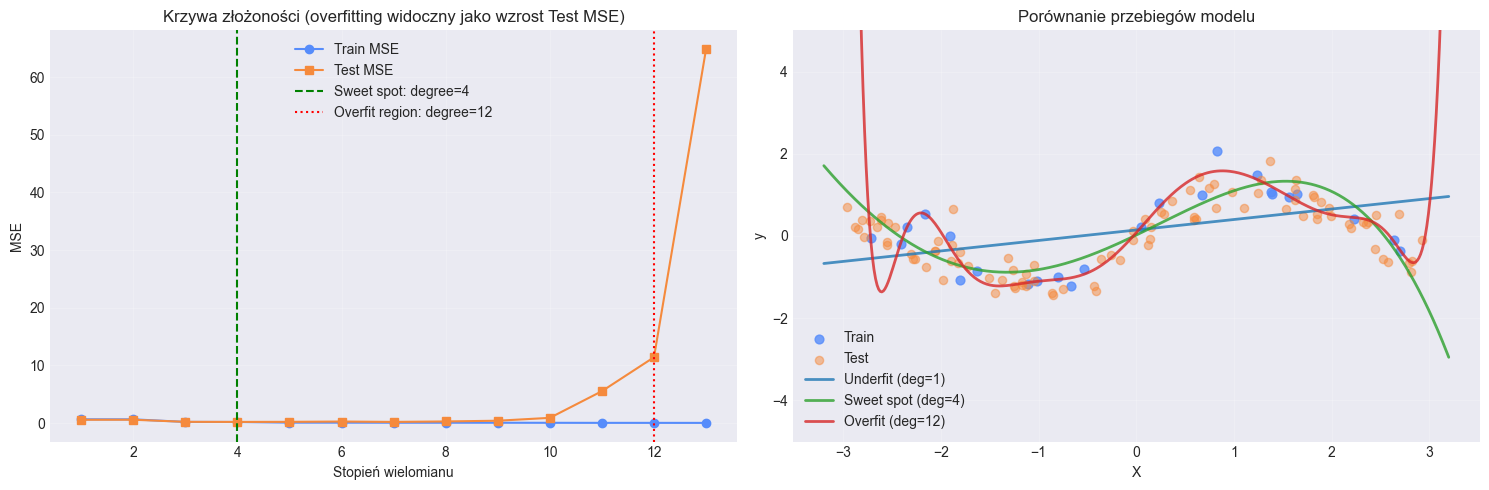

In [50]:
rng = np.random.RandomState(42)
n_samples = 120
X = rng.uniform(-3, 3, size=(n_samples, 1))
y_true = np.sin(1.5 * X[:, 0]) + 0.2 * X[:, 0]
y = y_true + rng.normal(0, 0.35, size=n_samples)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.20, random_state=42
)

degrees = np.arange(1, 14)
train_mse = []
test_mse = []

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=d, include_bias=False),
        LinearRegression()
    )
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_mse.append(mean_squared_error(y_train, y_pred_train))
    test_mse.append(mean_squared_error(y_test, y_pred_test))

best_idx = int(np.argmin(test_mse))
best_degree = int(degrees[best_idx])

overfit_degree = int(degrees[-2])
underfit_degree = 1

print(f"Best degree (min Test MSE): {best_degree}")
print(f"Underfit degree: {underfit_degree}, Overfit degree: {overfit_degree}")
print(f"Train MSE overfit: {train_mse[-2]:.4f}")
print(f"Test  MSE overfit: {test_mse[-2]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (A) Krzywa złożoności
axes[0].plot(degrees, train_mse, marker='o', label='Train MSE')
axes[0].plot(degrees, test_mse, marker='s', label='Test MSE')
axes[0].axvline(best_degree, color='green', linestyle='--', label=f'Sweet spot: degree={best_degree}')
axes[0].axvline(overfit_degree, color='red', linestyle=':', label=f'Overfit region: degree={overfit_degree}')
axes[0].set_xlabel('Stopień wielomianu')
axes[0].set_ylabel('MSE')
axes[0].set_title('Krzywa złożoności (overfitting widoczny jako wzrost Test MSE)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# (B) Dopasowania: underfit / sweet spot / overfit
x_plot = np.linspace(-3.2, 3.2, 400).reshape(-1, 1)
styles = [
    (underfit_degree, 'tab:blue', 'Underfit'),
    (best_degree, 'tab:green', 'Sweet spot'),
    (overfit_degree, 'tab:red', 'Overfit')
]

axes[1].scatter(X_train[:, 0], y_train, s=40, alpha=0.8, label='Train')
axes[1].scatter(X_test[:, 0], y_test, s=35, alpha=0.5, label='Test')

for d, c, lbl in styles:
    m = make_pipeline(PolynomialFeatures(degree=d, include_bias=False), LinearRegression())
    m.fit(X_train, y_train)
    y_plot = m.predict(x_plot)
    axes[1].plot(x_plot[:, 0], y_plot, alpha=0.8, color=c, linewidth=2, label=f'{lbl} (deg={d})')

axes[1].set_ylim(-5, 5)
axes[1].set_xlabel('X')
axes[1].set_ylabel('y')
axes[1].set_title('Porównanie przebiegów modelu')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Wnioski
W zakresie od stopnii 1-3 występuje underfitting, czyli model jest za prosty i nie potrafi jeszcze dobrze przewidywać wyników.

Najlepszy próg okazał się być stopniem 4, gdzie MSE jest minimalne.

Powyżej 4 stopnia dochodzi do przeuczenia, czyli do sytuacji, gdy model za bardzo dopasowuje się do danych treningowych, zapamiętując nawet szum i artefakty, zamiast uczyć się ogólnych wzorów. W efekcie model świetnie przewiduje dane treningowe, ale źle radzi sobie z nowymi danymi testowymi.

## Problem "Czarnego Labedzia" - ekstrapolacja dla regresji wielomianowej


Predykcje dla punktu anomalii (20% poza zakresem):
Underfitting (degree=1):  125.6568
Optimal (degree=4): 167857632.7961
Overfitting (degree=15): 2714416.4165


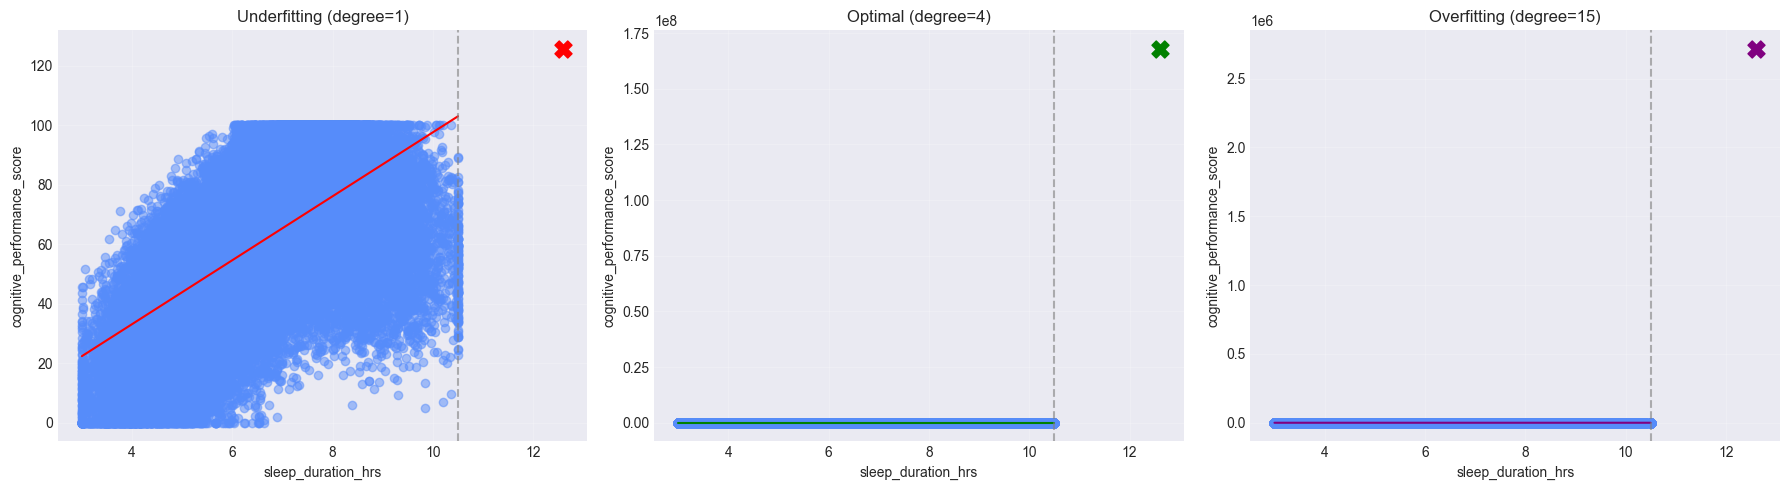

In [41]:
x_min_raw = x_train_raw.min()
x_max_raw = x_train_raw.max()
x_anomaly_raw = x_max_raw * 1.2

x_plot_raw = np.linspace(x_min_raw, x_max_raw, 200).reshape(-1, 1)
x_plot = (x_plot_raw - mean_feature) / scale_feature
x_anomaly = (np.array([[x_anomaly_raw]]) - mean_feature) / scale_feature

model_underfit = poly_models[0]
model_optimal = poly_models[best_degree_idx]
model_overfit = poly_models[14]

def predict_poly(model_bundle, x_values):
    X_poly = model_bundle["poly"].transform(x_values)
    return model_bundle["model"].predict(X_poly)

y_underfit_plot = predict_poly(model_underfit, x_plot)
y_optimal_plot = predict_poly(model_optimal, x_plot)
y_overfit_plot = predict_poly(model_overfit, x_plot)

y_underfit_anomaly = predict_poly(model_underfit, x_anomaly)[0]
y_optimal_anomaly = predict_poly(model_optimal, x_anomaly)[0]
y_overfit_anomaly = predict_poly(model_overfit, x_anomaly)[0]

print("\nPredykcje dla punktu anomalii (20% poza zakresem):")
print(f"Underfitting (degree=1):  {y_underfit_anomaly:.4f}")
print(f"Optimal (degree={best_degree}): {y_optimal_anomaly:.4f}")
print(f"Overfitting (degree=15): {y_overfit_anomaly:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(x_train_raw, y_train_reg, alpha=0.5)
axes[0].plot(x_plot_raw, y_underfit_plot, color='red')
axes[0].scatter([x_anomaly_raw], [y_underfit_anomaly], color='red', marker='X', s=150)
axes[0].axvline(x_max_raw, color='gray', linestyle='--', alpha=0.6)
axes[0].set_title('Underfitting (degree=1)')
axes[0].set_xlabel(feature_for_poly)
axes[0].set_ylabel('cognitive_performance_score')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(x_train_raw, y_train_reg, alpha=0.5)
axes[1].plot(x_plot_raw, y_optimal_plot, color='green')
axes[1].scatter([x_anomaly_raw], [y_optimal_anomaly], color='green', marker='X', s=150)
axes[1].axvline(x_max_raw, color='gray', linestyle='--', alpha=0.6)
axes[1].set_title(f'Optimal (degree={best_degree})')
axes[1].set_xlabel(feature_for_poly)
axes[1].set_ylabel('cognitive_performance_score')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(x_train_raw, y_train_reg, alpha=0.5)
axes[2].plot(x_plot_raw, y_overfit_plot, color='purple')
axes[2].scatter([x_anomaly_raw], [y_overfit_anomaly], color='purple', marker='X', s=150)
axes[2].axvline(x_max_raw, color='gray', linestyle='--', alpha=0.6)
axes[2].set_title('Overfitting (degree=15)')
axes[2].set_xlabel(feature_for_poly)
axes[2].set_ylabel('cognitive_performance_score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Wnioski
Zarówno dla modelu przeuczonego jak i dla modelu optymalnego, predykcja dla wartości wykraczającej poza zakres powoduje "eklozję" funkcji. Dzieje się tak z powodu dużych współczynników wielomianów.

Jest to sytuacja "Czarnego Łabędzia" - model działa poprawnie dla normalnego zakresu danych, jednak w momencie spotkania się z cechą o większej wartości dochodzi do katastrofy. Temu problemowi można przeciwdziałać między innymi redukując złożoność funkcji.